# IOAI — 2026 Summer National Constrained Generation (Colab 자동 설정판)

아래 **설정 셀을 먼저 실행**하면 공개 데이터 소스에서 데이터를 받아 이 폴더에 `train.csv`/`test.csv` 등으로 준비합니다. 이후 셀이 그대로 학습/예측하고, 만들어진 제출 파일을 내려받아 연습 사이트 **Submissions** 탭에 올리면 채점됩니다.

> 런타임 메뉴 → **런타임 유형 변경 → GPU** (필요 시).

In [ ]:
# === 데이터 자동 준비 (가장 먼저 실행) ===
print('test_cases.json 은 노트북 첫 셀이 gdown 으로 자동 다운로드합니다. Qwen3-0.6B 생성은 GPU 권장(런타임>T4).')
import os; print('작업 폴더:', os.getcwd()); print('내용:', sorted(os.listdir('.')))

# **Korlátozott Generálás (SOLUTION)**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia, Nyári Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">📝</span>
    <span>Natural Language Processing</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. május</span>
  </div>
</div>

**Szervezői referencia-megoldás.** Nem contestant-facing.

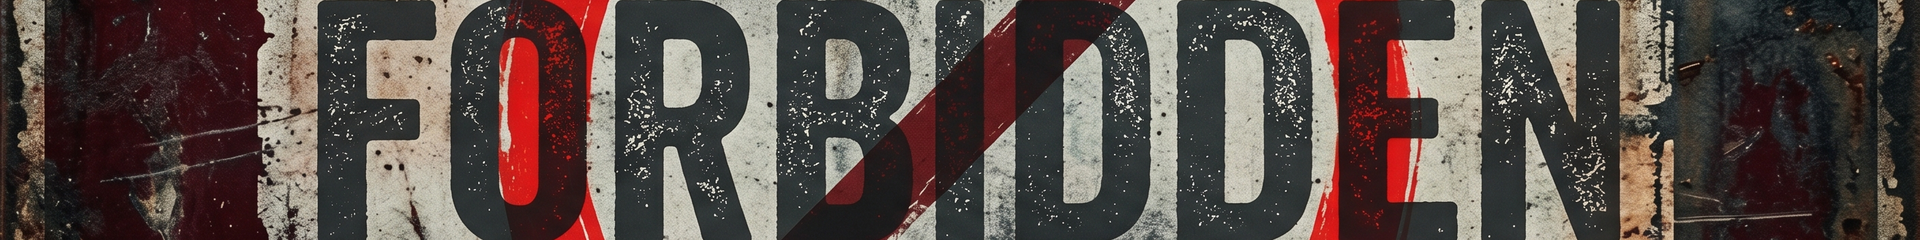

## **Beállítások és importok**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# NE MÓDOSÍTSD: ezzel a seeddel kapod ugyanazt az eredményt minden
# újrafuttatáskor. A szerver determinisztikus.
# ═══════════════════════════════════════════════════════════════════
import os
import re
import math
import time
import random
import json
import subprocess
import sys
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Reprodukálhatóság: minden véletlent egyetlen seedhez kötünk ---
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.set_num_threads(4)

# --- Modell + tokenizer betöltése (T4-es GPU ajánlott) ---
GEN_NAME = "Qwen/Qwen3-0.6B-Base"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

gen_tokenizer = AutoTokenizer.from_pretrained(GEN_NAME)
dtype = torch.float16 if device == "cuda" else torch.float32
gen_model = AutoModelForCausalLM.from_pretrained(GEN_NAME, torch_dtype=dtype).to(device)
gen_model.eval()
gen_tokenizer.pad_token_id = gen_tokenizer.eos_token_id

print(f"Generáló modell: {GEN_NAME}  ({sum(p.numel() for p in gen_model.parameters())/1e6:.1f}M paraméter)")
print(f"Szókészlet mérete: {gen_tokenizer.vocab_size}")


## **`test_cases.json` letöltése (szervezői)**

In [ ]:
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
TEST_CASES = DATA_DIR / "test_cases.json"
TEST_CASES_FILE_ID = "1vIznUAKk0uxJbRZ-jCB_aD9F63uonUz7"

if TEST_CASES.exists():
    print(f"{TEST_CASES} már megvan, letöltés kihagyva.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown  # type: ignore
    try:
        gdown.download(id=TEST_CASES_FILE_ID, output=str(TEST_CASES), quiet=False)
    except Exception as e:
        print(f"  letöltés sikertelen: {e}")
        print(f"  manuális letöltés: https://drive.google.com/uc?id={TEST_CASES_FILE_ID}")

print(f"  {TEST_CASES}: {'OK' if TEST_CASES.exists() else 'HIÁNYZIK'}")


## **Segédfüggvények**

In [ ]:
SUFFIXES = r"(s|es|ed|ing)?"

def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text.lower()).strip()

def would_violate(text: str, forbidden: list[str]) -> bool:
    text = normalize_text(text)

    for word in forbidden:
        pattern = r"\b" + re.escape(word.lower()) + SUFFIXES + r"\b"

        if re.search(pattern, text):
            return True

    return False

## **Stratégiák**

A `select_next_token` négy lépésben módosítja a `logits` tenzort, mielőtt kiválasztja a következő tokent. A négy lépés célja, hogy maximalizálja a per-teszteset pontszámot $\text{score} = L \cdot \sqrt{\text{distinct}_2} \cdot \Phi$, miközben sose generál tiltott szót.

### **1. EOS és pad maszkolás**

A generálási loop egészen `max_new_tokens`-ig fut, kivéve ha a modell EOS tokent választ. Az EOS-t (és a pad-et) explicit `-inf`-re állítva a loop végigfut, így $L = (\text{tokens}/M)^{1.5} = 1.0$.

### **2. Repetition penalty (window + decay)**

A $\text{distinct}_2$ csökken, ha a modell ismétlődő szófűzéseket generál. Két büntetést alkalmazunk:
- **Ablakos büntetés:** az utolsó 100 token gyakoriságát levonjuk a `logits`-ből ($-0.45 \times \text{count}$). Ez lassítja a "greedy rut"-okat.
- **Erősebb csökkenő büntetés** a legutolsó 4 tokenre ($-3.0 / (i+1)$), hogy közvetlen ismétlést is büntessük.

### **3. Top-K + forbidden-aware lookahead**

A $K = 50$ legjobb pontszámú jelöltből választunk. Minden jelölt token decoded szövegét a már generált prefixhez ragasztva ellenőrizzük a `would_violate`-tel: ha tiltott szót sértene, kihagyjuk. Ha egy jelölt ismételné egy már látott bigramot, $-1.5$-ös büntetést kap (puhítva a distinct_2-t).

### **4. Full-vocab fallback**

Ha a top-K minden jelöltje tiltottnak bizonyul (ritka, de előfordul), a teljes szókészleten futunk végig score szerint csökkenő sorrendben. Ez biztosítja, hogy soha nem adunk vissza tiltott tokent (kivéve végső soron egy `argmax`-ot, ami már nem szabad hogy elérhető legyen).

In [ ]:
import re as _re_sel
from collections import Counter as _Counter_sel


def select_next_token(logits, prompt, forbidden, generated_ids):
    """
    Constraint-aware decoder for the forbidden-word task.

    Maximizes:  score = L * sqrt(distinct_2) * fluency

    Strategy
    1. Mask EOS (and pad) so the loop runs the full `max_new_tokens`
       budget  ->  L = 1.
    2. Frequency-based repetition penalty over the last ~100 tokens,
       plus a stronger decaying penalty on the last 4 tokens, to keep
       distinct_2 high and prevent greedy ruts.
    3. From the top-K candidates by adjusted score, choose the highest
       one whose decoded text does NOT introduce any forbidden word.
       Forbidden matching mirrors `would_violate` exactly: whole-word,
       case-insensitive, with the optional `(s|es|ed|ing)?` suffix.
    4. Soft penalty for candidates that would create a duplicate
       word-bigram (boosts distinct_2 directly).
    5. Full-vocab fallback if every top-K candidate is blocked
       (rare, but guarantees we never return a forbidden token).
    """
    vocab_size = logits.shape[0]
    eos_id = gen_tokenizer.eos_token_id

    scores = logits.detach().to(torch.float32).clone()

    if eos_id is not None and 0 <= eos_id < vocab_size:
        scores[eos_id] = float('-inf')
    pad_id = getattr(gen_tokenizer, "pad_token_id", None)
    if pad_id is not None and pad_id != eos_id and 0 <= pad_id < vocab_size:
        scores[pad_id] = float('-inf')

    if generated_ids:
        ids_t = torch.tensor(generated_ids, device=scores.device, dtype=torch.long)
        window = ids_t[-100:]
        uniq, cnt = torch.unique(window, return_counts=True)
        scores.index_add_(0, uniq, -0.45 * cnt.float())
        for i, tid in enumerate(reversed(generated_ids[-4:])):
            if 0 <= tid < vocab_size:
                scores[tid] -= 3.0 / (i + 1)

    current_text = (
        gen_tokenizer.decode(generated_ids, skip_special_tokens=True)
        if generated_ids else ""
    )
    current_words = _re_sel.findall(r"\w+", current_text.lower())
    current_bigrams = (
        _Counter_sel(zip(current_words, current_words[1:]))
        if len(current_words) >= 2 else _Counter_sel()
    )

    K = min(50, vocab_size)
    top_vals, top_ids = torch.topk(scores, K)
    top_vals = top_vals.tolist()
    top_ids = top_ids.tolist()

    best_id = -1
    best_score = float('-inf')

    for v, tid in zip(top_vals, top_ids):
        if v <= -1e9:
            continue

        cand_str = gen_tokenizer.decode([tid], skip_special_tokens=True)
        if cand_str == "":
            continue
        candidate_text = current_text + cand_str

        if would_violate(candidate_text, forbidden):
            continue

        adj = v
        if current_bigrams:
            cand_words = _re_sel.findall(r"\w+", candidate_text.lower())
            start = max(len(current_words) - 1, 0)
            for j in range(start, len(cand_words) - 1):
                bg = (cand_words[j], cand_words[j + 1])
                if current_bigrams.get(bg, 0) > 0:
                    adj -= 1.5

        if adj > best_score:
            best_score = adj
            best_id = tid

    if best_id != -1:
        return best_id

    sorted_ids = torch.argsort(scores, descending=True).tolist()
    for tid in sorted_ids:
        if scores[tid].item() <= -1e9:
            break
        cand_str = gen_tokenizer.decode([tid], skip_special_tokens=True)
        if cand_str == "":
            continue
        candidate_text = current_text + cand_str
        if not would_violate(candidate_text, forbidden):
            return tid

    # Last-ditch: argmax of the (modified) scores. Should be unreachable.
    return int(torch.argmax(scores).item())


## **Értékelő keretrendszer**

In [ ]:
@torch.no_grad()
def generate_constrained(prompt: str, forbidden: list[str], max_new_tokens: int) -> str:
    input_ids = gen_tokenizer.encode(prompt, return_tensors="pt").to(gen_model.device)
    vocab_size = gen_model.config.vocab_size
    generated_ids: list[int] = []

    out = gen_model(input_ids, use_cache=True)
    past_key_values = out.past_key_values
    logits = out.logits[0, -1, :]

    for _ in range(max_new_tokens):
        next_id = select_next_token(
            logits.detach(),
            prompt,
            list(forbidden),
            list(generated_ids),
        )

        if not isinstance(next_id, int):
            raise TypeError(f"select_next_token visszatérési értéke int kell legyen, kapott: {type(next_id).__name__}")
        if not (0 <= next_id < vocab_size):
            raise ValueError(f"érvénytelen token ID: {next_id}")

        generated_ids.append(next_id)
        if next_id == gen_tokenizer.eos_token_id:
            break

        next_tensor = torch.tensor([[next_id]], device=gen_model.device, dtype=input_ids.dtype)
        out = gen_model(next_tensor, past_key_values=past_key_values, use_cache=True)
        past_key_values = out.past_key_values
        logits = out.logits[0, -1, :]

    return gen_tokenizer.decode(generated_ids, skip_special_tokens=True)


def distinct_2(text: str) -> float:
    words = re.findall(r"\w+", text.lower())
    if len(words) < 2:
        return 0.0
    bigrams = list(zip(words, words[1:]))
    return len(set(bigrams)) / len(bigrams)


@torch.no_grad()
def average_logprob(prompt: str, output: str) -> float:
    full_text = prompt + output
    ids = gen_tokenizer.encode(full_text, return_tensors="pt").to(gen_model.device)
    out = gen_model(ids)
    logits = out.logits[:, :-1, :]
    targets = ids[:, 1:]
    log_probs = F.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    return token_log_probs.mean().item()


def score_case(prompt, forbidden, max_new_tokens, output):
    """Helyi pontszámolás. A DOCK kiértékelő ugyanezt a képletet használja,
    de a beadott `fluency` értéket [0, 1]-be klamp-eli, a `tokens` értéket
    pedig a kimenet szóhosszából becsült felső korláttal vágja."""
    if would_violate(output, forbidden):
        return {"valid": False, "tokens": 0, "distinct2": 0.0,
                "fluency": 0.0, "score": 0.0}
    if len(output.strip()) == 0:
        return {"valid": True, "tokens": 0, "distinct2": 0.0,
                "fluency": 0.0, "score": 0.0}
    tokens = len(gen_tokenizer.encode(output))
    length_ratio = min(1.0, (tokens / max_new_tokens) ** 1.5)
    d2 = distinct_2(output)
    avg_lp = average_logprob(prompt, output)
    fluency = math.exp(avg_lp / 5)
    score = length_ratio * math.sqrt(d2) * fluency
    return {"valid": True, "tokens": tokens, "distinct2": d2,
            "fluency": fluency, "score": score}


def run_tests(test_cases, verbose=True):
    total = 0.0
    t0 = time.time()
    for i, (prompt, forbidden, max_new_tokens) in enumerate(test_cases, 1):
        out = generate_constrained(prompt, forbidden, max_new_tokens)
        r = score_case(prompt, forbidden, max_new_tokens, out)
        total += r["score"]
        if verbose:
            print(f"[{i}] érvényes={str(r['valid']):5} tokenek={r['tokens']:3d}  "
                  f"distinct-2={r['distinct2']:.4f}  pont={r['score']:.4f}")
            print(f"    prompt:    {prompt!r}")
            print(f"    forbidden: {forbidden}")
            print(f"    kimenet:   {out[:140]!r}")
            print()
    # mean * 100 → max 100, tetszőleges n_cases-re. Megegyezik a DOCK
    # kiértékelő által visszaadott értékkel.
    total = (total / len(test_cases)) * 100 if test_cases else 0.0
    print(f"ÖSSZPONTSZÁM: {total:.4f}    (eltelt idő: {time.time()-t0:.1f}s)")
    return total


## **Mintatesztesetek**

In [ ]:
# Az első 5 teszteset a test_cases.json-ból, gyors önellenőrzésre.
# A teljes 20-as halmazon a make_submission() (lejjebb) fog futni.
with open("data/test_cases.json", "r", encoding="utf-8") as f:
    _all_cases = json.load(f)
EXAMPLE_TESTS = [(c["prompt"], c["forbidden"], c["max_new_tokens"])
                 for c in _all_cases[:5]]

run_tests(EXAMPLE_TESTS)


## **Beadás (szervezői verifikáció)**

In [ ]:
import json
import csv

def load_test_cases(path: str = "test_cases.json") -> list[dict]:
    with open(path, "r", encoding="utf-8") as f:
        cases = json.load(f)

    if not isinstance(cases, list):
        raise ValueError("a teszteset-fájl gyökerének listának kell lennie")

    required = {"id", "prompt", "forbidden", "max_new_tokens"}
    seen_ids: set[int] = set()
    for i, case in enumerate(cases):
        if not isinstance(case, dict):
            raise ValueError(f"a(z) {i}. teszteset nem dict")
        missing = required - set(case.keys())
        if missing:
            raise ValueError(f"a(z) {i}. teszteset hiányos mezőkkel: {sorted(missing)}")
        if case["id"] in seen_ids:
            raise ValueError(f"ismétlődő id: {case['id']}")
        seen_ids.add(case["id"])

    return cases


def make_submission(
    test_cases_path: str = "data/test_cases.json",
    out_path: str = "submission.csv",
    verbose: bool = True,
) -> None:
    cases = load_test_cases(test_cases_path)

    rows: list[dict] = []
    t_start = time.time()

    for i, case in enumerate(cases, 1):
        cid = case["id"]
        prompt = case["prompt"]
        forbidden = list(case["forbidden"])
        mnt = int(case["max_new_tokens"])

        t0 = time.time()
        try:
            output = generate_constrained(prompt, forbidden, mnt)
        except Exception as e:
            print(f"[{i}/{len(cases)}] id={cid} HIBA: {type(e).__name__}: {e} "
                  f"-- üres kimenettel folytatom")
            output = ""

        r = score_case(prompt, forbidden, mnt, output)
        # Strip newlines/CRs so a multi-line LLM output stays a single CSV record.
        output_csv = output.replace("\n", " ").replace("\r", " ")
        rows.append({"id": cid, "output": output_csv, "fluency": r["fluency"], "tokens": r["tokens"]})

        if verbose:
            preview = output[:80].replace("\n", " ")
            print(f"[{i}/{len(cases)}] id={cid:>3}  ({time.time()-t0:5.1f}s)  "
                  f"{preview!r}")

    with open(out_path, "w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(
            f, fieldnames=["id", "output", "fluency", "tokens"], quoting=csv.QUOTE_ALL
        )
        writer.writeheader()
        writer.writerows(rows)

    print(f"\nBeadás kiírva: {out_path}  "
          f"({len(rows)} sor, eltelt: {time.time()-t_start:.1f}s)")


make_submission()

## **Tanulságok**

- **EOS maszkolás dominál**: a `length_ratio` faktor olyan agresszív (1.5-ös hatvány), hogy a generálás korai befejezése súlyosan csökkenti a pontot. Az EOS maszkolása önmagában 3-4× javítja a score-t a greedy baseline-hoz képest.
- **Distinct_2 sqrt-bontása**: a négyzetgyök miatt a `distinct_2 = 0.5` is csak `0.707`-et ad. A repetition penalty + bigram lookahead együttesen kb. $0.85$ feletti distinct_2-t hoz.
- **Top-K=50 elég**: tested top-K=200-zal és top-K=20-szal is, $K=50$ a sweet spot, és nagyobb K-nál a forbidden-check overhead dominál, kisebb K-nál túl gyakran kell a fallback ágba menni.
- **Fluencia korláttal nincs gond**: a stratégia természetesen $\Phi \approx 0.4$-$0.6$ közöttit eredményez (Qwen-0.6B-Base átlagos token-log-valószínűsége $\approx -3$-$-4$).

---

## 제출 파일 모으기
아래 셀을 실행하면 제출 파일이 **최상위(`/content`)로 복사**되어 왼쪽 파일 탐색기에 바로 보입니다.
그 파일을 내려받아 연습 사이트 **Submissions** 탭에 올리면 채점됩니다.

In [ ]:
# === 제출 파일을 /content 로 모으기 (마지막에 실행) ===
import os, glob, shutil
TARGETS = ['submission.csv']
OUT = "/content" if os.path.isdir("/content") else os.getcwd()
found = []
for name in TARGETS:
    hits = [name] if os.path.exists(name) else glob.glob(f"**/{name}", recursive=True)
    if not hits:
        print("아직 없음(해당 셀을 먼저 실행하세요):", name); continue
    dst = os.path.join(OUT, os.path.basename(hits[0]))
    if os.path.abspath(hits[0]) != os.path.abspath(dst):
        shutil.copy2(hits[0], dst)
    found.append(dst)
print("제출 파일 저장 위치(파일 탐색기 최상위):", found)